In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from kde_error import weighted_kde_with_se
from tqdm import tqdm

In [2]:
def load_plumed(fname):
    data = {}
    with open(fname, 'r') as f:
        fields = f.readline()[:-1].split(" ")[2:] # last char is '/n' and the first two are '#!' and 'FIELDS'
        for field in fields: # add fields to the colvars dict
            data[field] = []
        line = f.readline()
        while line: # read up to LINE_LIM lines
            if line[0] == "#": # Don't read comments
                line = f.readline()
                continue
            line_list = line.split()
            if len(line_list) != len(fields):
                line = f.readline()
                continue
            for i, field in enumerate(fields):
                data[field].append(float(line_list[i]))
            line = f.readline()
    data = pd.DataFrame(data)
    return data

def get_fe_kde(data):
    data_points = np.column_stack([data.chi1.to_numpy(), data.chi2.to_numpy()])
    kernel = gaussian_kde(data_points[::10].T, weights=data.weights.to_numpy()[::10])
    xmin, xmax = -7.0, 7.0
    ymin, ymax = -5.0, 5.0
    X, Y = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    free_energy = -(8.314*400)*np.log(np.reshape(kernel(positions).T, X.shape))/1000
    free_energy -= free_energy.min()
    return X, Y, free_energy

def get_fe_kde_1d(data):
    data_points = data.chi1.to_numpy()
    kernel = gaussian_kde(data_points, weights=data.weights.to_numpy())
    xmin, xmax = -7.0, 7.0
    X = np.linspace(xmin, xmax, 1000)
    free_energy = -(8.314*400)*np.log(np.reshape(kernel(X).T, X.shape))/1000
    free_energy_masked = free_energy.copy()
    free_energy_masked[free_energy_masked>1e2] = np.nan
    free_energy_masked -= np.nanmean(free_energy_masked)
    return X, free_energy_masked

def get_fe_kde_1d_srv(data):
    data_points = data["model.node-0"].to_numpy()
    kernel = gaussian_kde(data_points, weights=data.weights.to_numpy())
    xmin, xmax = -7.0, 7.0
    X = np.linspace(xmin, xmax, 1000)
    free_energy = -(8.314*400)*np.log(np.reshape(kernel(X).T, X.shape))/1000
    free_energy_masked = free_energy.copy()
    #free_energy_masked[free_energy_masked>1e2] = np.nan
    #free_energy_masked -= np.nanmean(free_energy_masked)
    return X, free_energy_masked

def get_chi(CVs):
    sin_vals = np.sin(CVs) # in rad
    lambdas = np.sum(sin_vals, axis=1)* (-0.8)
    chi1 = lambdas[:, 2:7].sum(axis=1)
    chi2 =  lambdas[:, 2] + lambdas[:, 3] - lambdas[:, 5] - lambdas[:, 6]
    return chi1, chi2

In [3]:
data = load_plumed("COLVAR_RBIAS")
data.head(5)

,time,phi1,phi2,phi3,phi4,phi5,phi6,phi7,phi8,phi9,...,psi2,psi3,psi4,psi5,psi6,psi7,psi8,psi9,model.node-0,metad.bias
0,0.0,-1.492030,-1.380106,-0.903696,0.887787,1.038738,-1.344710,-1.096940,-1.458038,-1.009562,...,-0.450843,1.960128,0.658830,0.564415,-0.500246,-0.546820,-0.891771,-0.814546,-0.110772,206.478460
1,1.0,-1.017265,-1.115314,-0.808501,1.080280,1.088777,-0.614072,-1.189391,-1.217078,-1.439161,...,-0.752126,1.809847,0.623325,0.569184,-0.967449,-0.678617,-0.683260,-0.582921,-0.434746,207.571330
2,2.0,-1.097057,-1.039698,-0.894150,0.919394,1.106712,-0.991659,-0.949413,-1.118329,-1.395562,...,-0.802878,1.952491,0.769004,0.383385,-0.656620,-0.769714,-0.885884,-0.242025,-0.467615,207.502512
3,3.0,-1.210505,-1.093723,-1.071533,1.036778,1.047063,-0.856966,-0.914598,-1.011844,-1.298950,...,-0.548288,1.963321,0.473790,0.681243,-0.912620,-0.986606,-0.848017,-0.726675,-0.393149,207.477095
4,4.0,-0.794444,-0.527507,-0.867760,0.800010,0.969264,-1.145661,-1.003003,-1.256559,-1.655055,...,-1.049476,1.867346,0.691343,0.727297,-0.798799,-0.699360,-0.687857,-0.099442,-0.564200,207.311549


In [4]:
print(len(data))
CUTOFF = 1_000_000

2000001


In [5]:
data["weights"] = np.exp(data["metad.bias"]/(0.008314*400))

In [6]:
phi = np.stack([data[f"phi{i}"] for i in range(1, 10)], axis=1)
psi = np.stack([data[f"psi{i}"] for i in range(1, 10)], axis=1)
angs = np.stack([phi, psi], axis=1)

chi1, chi2 = get_chi(angs)

data['chi1'] = chi1
data['chi2'] = chi2

In [ ]:
grid = np.linspace(-7, 7, 400)
density, se, info = weighted_kde_with_se(data.iloc[CUTOFF:, :].chi1, data.iloc[CUTOFF:, :].weights, grid)

kBT = 400*8.314/1000 # kJ/mol at ~400 K
eps = 1e-12

F = -kBT * np.log(np.clip(density, eps, None))
F_err = kBT * se / np.clip(density, eps, None)

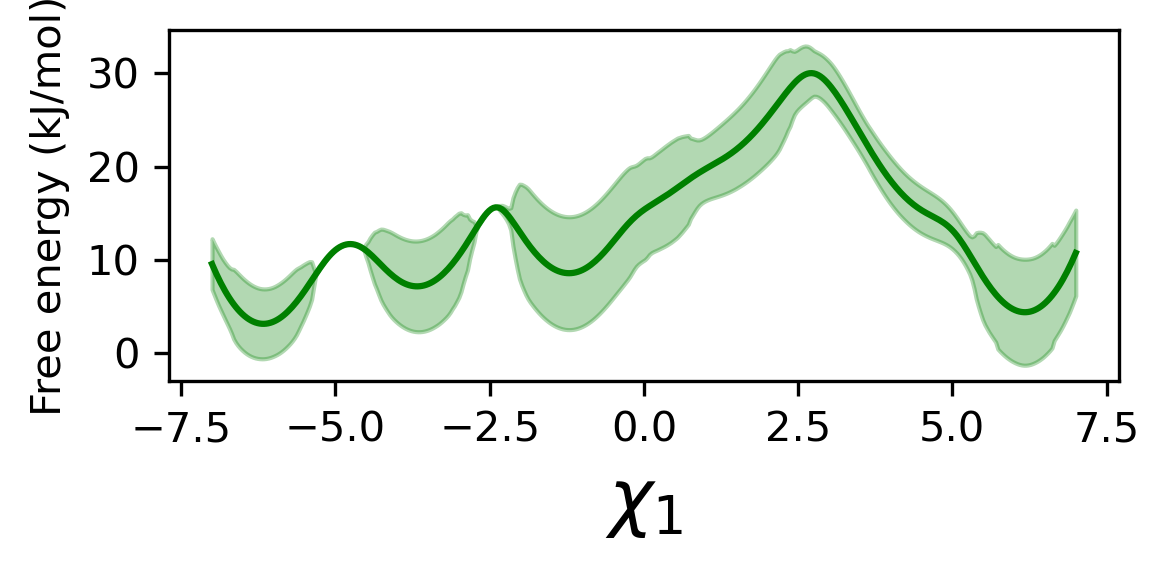

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 2), dpi=300)
ax.plot(grid, F, label="Free energy", color='green')
ax.fill_between(grid, F - 1.96 * F_err, F + 1.96 * F_err, alpha=0.3, label="1.96×SE band", color='green')
ax.set_xlabel(r"$\chi_1$", fontsize=18)
ax.set_ylabel("Free energy (kJ/mol)")
fig.tight_layout()
plt.show()

In [12]:
X, Y, Z_main = get_fe_kde(data.iloc[CUTOFF:, :])

In [ ]:
vmin = 0
vmax = 30
n_levels = 101
levels = np.linspace(vmin, vmax, n_levels)

cmap = plt.cm.magma
colors = [cmap(i / (n_levels - 2)) for i in range(n_levels - 1)]
colors[-1] = 'white'

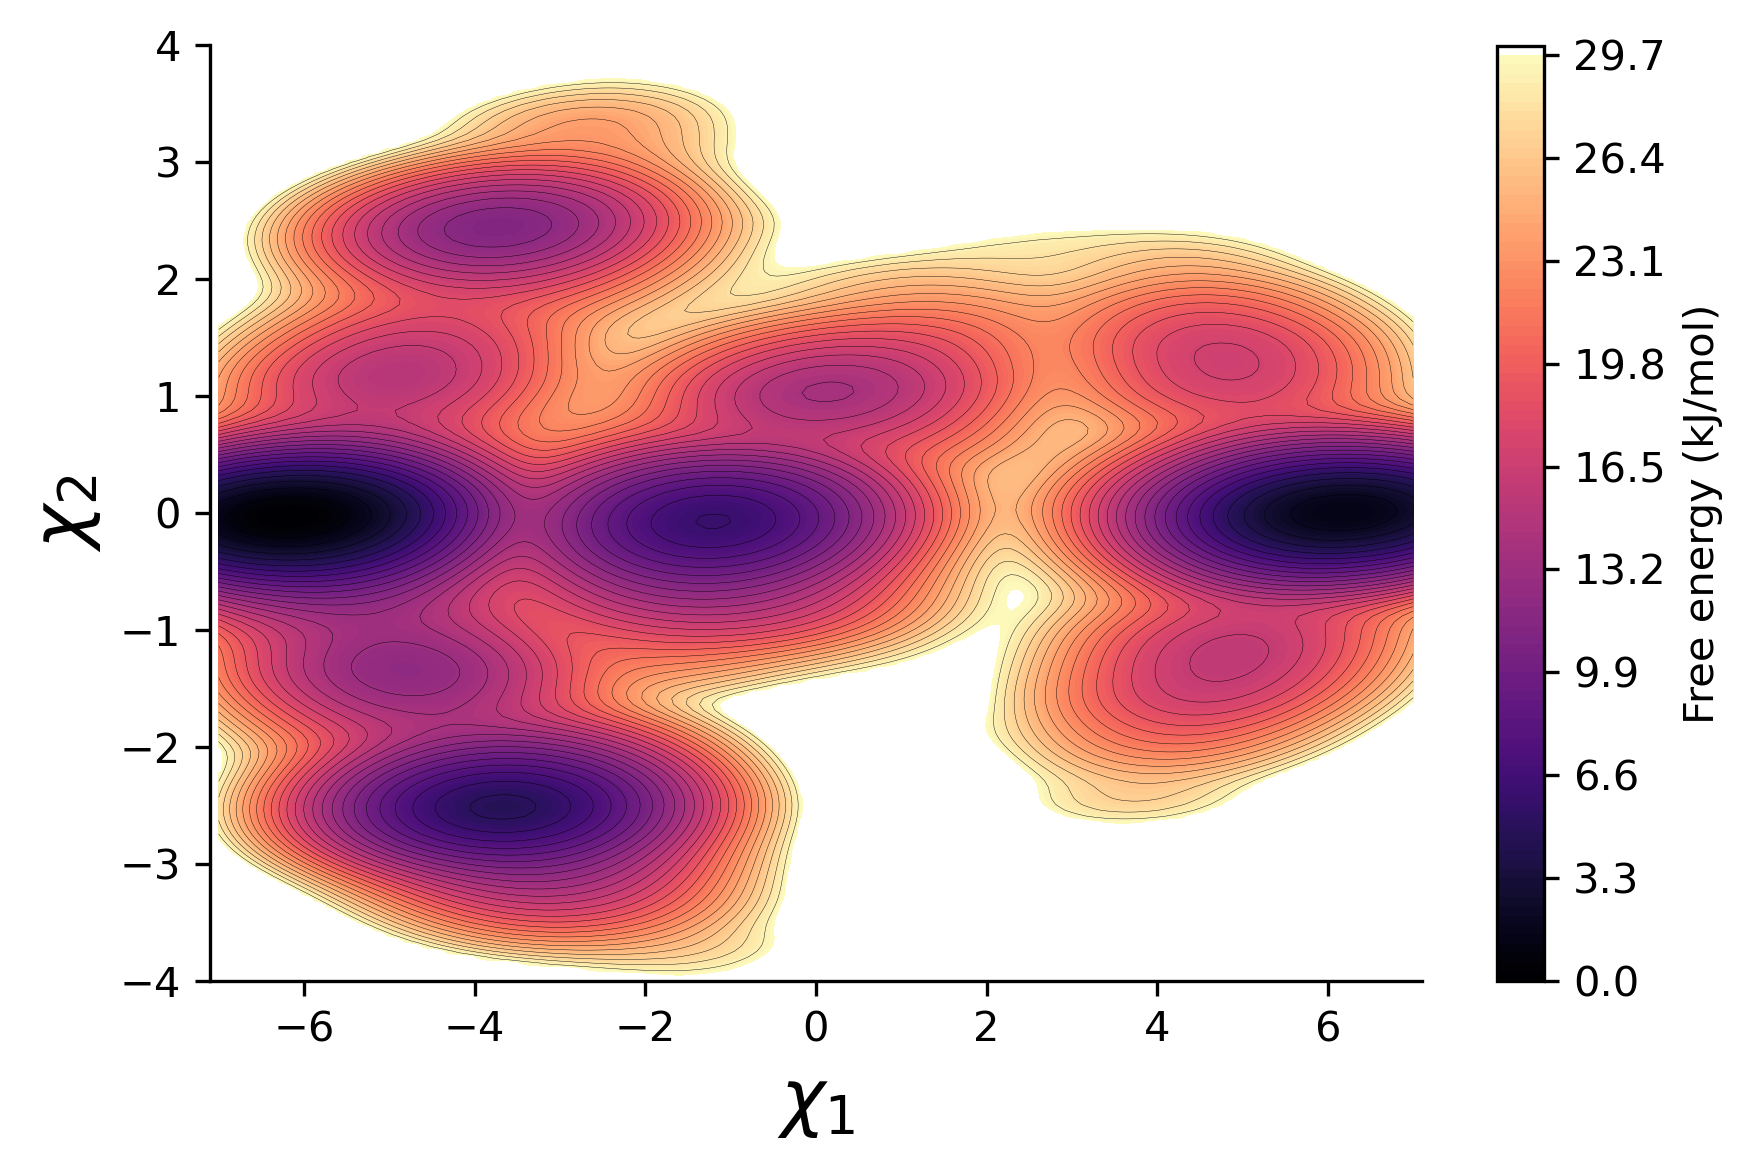

In [ ]:
Z = np.where(Z_main>vmax, vmax, Z_main)
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=300)

contour = ax.contourf(X, Y, Z, levels=levels, colors=colors, alpha=1.0, vmax=vmax)
plt.colorbar(contour, ax=ax, label='Free energy (kJ/mol)', extend='max')

# KDE contour lines
contour_lines = ax.contour(X, Y, Z, levels=30, colors='k', linewidths=0.1, alpha=1.0, vmax=vmax)

ax.set_xlabel(r"$\chi_1$", fontsize=18)
ax.set_ylabel(r"$\chi_2$", fontsize=18)
ax.set_xlim(-7.1, 7.1)
ax.set_ylim(-4, 4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()